In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv("../Datasets/dapt2020.csv")

df["Stage"] = df["Stage"].replace({"BENIGN": "Benign"})
df["Activity"] = df["Activity"].replace({"BENIGN": "Normal"})

In [2]:
# Display the first few rows of the dataset
print(">> Dataset Overview:")
df.head()

>> Dataset Overview:


,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Activity,Stage
0,0.0,0.0,0.0,119998944.0,242.0,1.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,Normal,Benign
1,53569.0,8662.0,17.0,109235816.0,21.0,1.0,1072.0,52.0,56.0,48.0,...,819535.500000,78517.844090,875056.0,764015.0,1.517532e+07,6.349189e+06,20019201.0,5202524.0,Normal,Benign
2,68.0,67.0,17.0,119764062.0,88.0,1.0,25515.0,289.0,296.0,288.0,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,Normal,Benign
3,40504.0,9200.0,6.0,117030424.0,18.0,17.0,23499.0,3736.0,4096.0,0.0,...,192329.333333,436593.123269,1083374.0,7236.0,1.931131e+07,1.177830e+07,34978598.0,5147962.0,Normal,Benign
4,0.0,0.0,0.0,119999703.0,2.0,1.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,5.999985e+07,8.478210e+02,60000451.0,59999252.0,Normal,Benign


In [3]:
# Display basic information about the dataset
print("\n>> Dataset Information:")
df.info()


>> Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86690 entries, 0 to 86689
Data columns (total 81 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Src Port                    82577 non-null  float64
 1   Dst Port                    82577 non-null  float64
 2   Protocol                    82577 non-null  float64
 3   Flow Duration               82577 non-null  float64
 4   Total Fwd Packet            82577 non-null  float64
 5   Total Bwd packets           82577 non-null  float64
 6   Total Length of Fwd Packet  82577 non-null  float64
 7   Total Length of Bwd Packet  82577 non-null  float64
 8   Fwd Packet Length Max       82577 non-null  float64
 9   Fwd Packet Length Min       82577 non-null  float64
 10  Fwd Packet Length Mean      82577 non-null  float64
 11  Fwd Packet Length Std       82577 non-null  float64
 12  Bwd Packet Length Max       82577 non-null  float64
 13  Bwd Pa

In [4]:
# Display summary statistics
print("\n>> Summary Statistics:")
df.describe()


>> Summary Statistics:


,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,82577.000000,82577.000000,82577.000000,8.257700e+04,82577.000000,82577.000000,8.257700e+04,8.257700e+04,82577.000000,82577.000000,...,82577.000000,82577.0,8.257700e+04,8.257700e+04,8.257700e+04,8.257700e+04,8.257700e+04,8.257700e+04,8.257700e+04,8.257700e+04
mean,39894.209610,8138.424925,9.146082,2.052417e+07,56.409606,80.873415,2.030443e+04,4.322426e+04,226.423605,21.675358,...,14.991450,0.0,5.853183e+05,2.425891e+05,8.606169e+05,3.494524e+05,3.826881e+06,6.290809e+05,4.525703e+06,3.217837e+06
std,18883.995405,14065.843842,5.461515,4.149541e+07,2572.795881,5146.954432,1.900680e+06,8.230808e+05,935.452890,89.288104,...,241.503525,0.0,2.978022e+06,1.271591e+06,3.829862e+06,2.240449e+06,1.128227e+07,2.737022e+06,1.262060e+07,1.063923e+07
min,0.000000,0.000000,0.000000,4.000000e+00,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,36218.000000,53.000000,6.000000,4.260000e+02,1.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,47232.000000,445.000000,6.000000,1.578300e+04,1.000000,3.000000,4.500000e+01,2.280000e+02,45.000000,0.000000,...,1.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,53141.000000,9002.000000,17.000000,2.116769e+06,8.000000,5.000000,6.020000e+02,4.890000e+02,122.000000,45.000000,...,1.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65475.000000,65432.000000,17.000000,1.200000e+08,259089.000000,518384.000000,2.534673e+08,9.548315e+07,64440.000000,11584.000000,...,58252.000000,0.0,9.313144e+07,5.660562e+07,9.313144e+07,9.313144e+07,1.197569e+08,6.146251e+07,1.197569e+08,1.197569e+08


In [5]:
# Check for missing values
print("\n>> Missing Values:")
df.isnull().sum()
print(f">> Shape: {df.shape}")


>> Missing Values:
>> Shape: (86690, 81)


In [6]:
df.dropna(inplace=True)
print("\n>> Rows with Missing Values Removed!")
print(f">> New Dataset Shape: {df.shape}")


>> Rows with Missing Values Removed!
>> New Dataset Shape: (82577, 81)


In [7]:
# Drop unnecessary columns
drop_features = [
    "Flow ID", "Src IP", "Dst IP", "Src Port", "Timestamp", 
    "Fwd PSH Flags", "Fwd URG Flags", "Bwd URG Flags", "URG Flag Cnt", 
    "Fwd Byts/b Avg", "Fwd Pkts/b Avg", "Fwd Blk Rate Avg", 
    "Bwd Byts/b Avg", "Bwd Pkts/b Avg", "Bwd Blk Rate Avg", "Fwd Seg Size Min"
]
df.drop(columns=drop_features, inplace=True, errors="ignore")
print("\n>> Dropped Unnecessary Features! Remaining Columns:")
df.columns.tolist()


>> Dropped Unnecessary Features! Remaining Columns:


['Dst Port',
 'Protocol',
 'Flow Duration',
 'Total Fwd Packet',
 'Total Bwd packets',
 'Total Length of Fwd Packet',
 'Total Length of Bwd Packet',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Bwd PSH Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Packet Length Min',
 'Packet Length Max',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'URG Flag Count',
 'CWR Flag Count',
 'ECE Flag Count',
 'Do


>> Visualizing Stage Column Distribution...


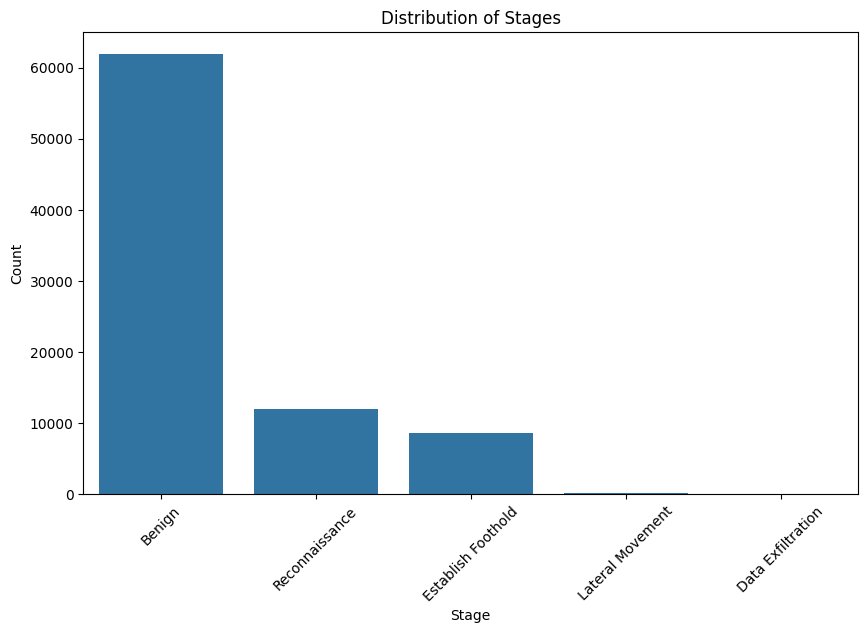

In [8]:
# Visualize the distribution of the Stage column
print("\n>> Visualizing Stage Column Distribution...")
plt.figure(figsize=(10, 6))
sns.countplot(x=df["Stage"], order=df["Stage"].value_counts().index)
plt.title("Distribution of Stages")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


>> Visualizing Activity Column Distribution...


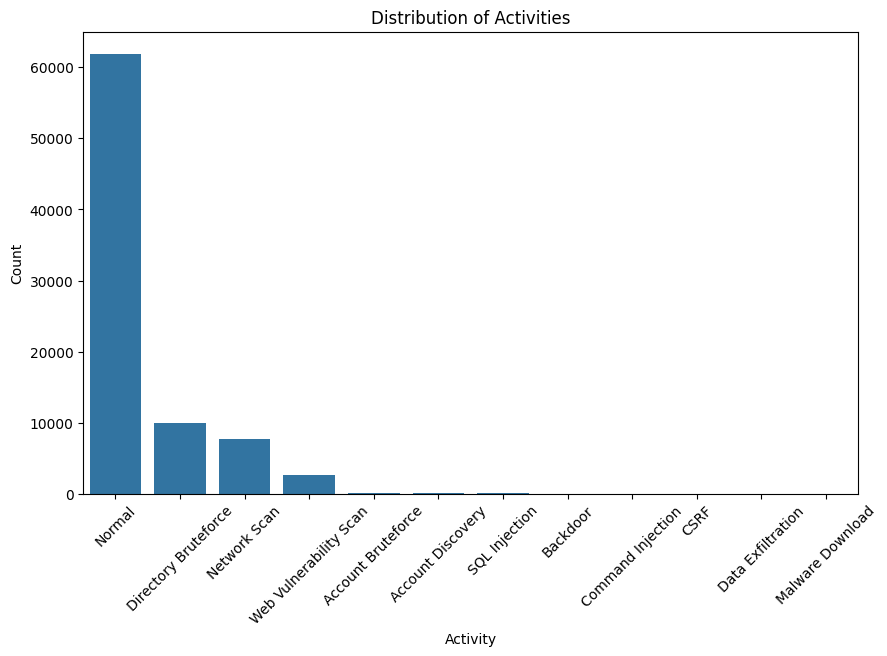

In [9]:
# Visualize the distribution of the Activity column
print("\n>> Visualizing Activity Column Distribution...")
plt.figure(figsize=(10, 6))
sns.countplot(x=df["Activity"], order=df["Activity"].value_counts().index)
plt.title("Distribution of Activities")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [10]:
# Create label columns
print("\n>> Creating Label Columns...")
df["Binary_Label"] = df["Stage"].apply(lambda x: 0 if x == "Benign" or x == "BENIGN" else 1)
multiclass_mapping = {
    "Normal": 0, "Reconnaissance": 1, "Foothold Establishment": 2,
    "Lateral Movement": 3, "Data Exfiltration": 4
}
df["Multiclass_Label"] = df["Stage"].map(multiclass_mapping)
print(">> Label Columns Created!")

# Select numeric feature columns
feature_cols = [col for col in df.columns if col not in ["Stage", "Binary_Label", "Multiclass_Label"]]
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")
df.fillna(0, inplace=True)
X = df[feature_cols].values.astype(float)
print(f"\n>> Feature Extraction Completed! Number of Features: {len(feature_cols)}")


>> Creating Label Columns...
>> Label Columns Created!

>> Feature Extraction Completed! Number of Features: 75


In [11]:
# Normalize features
print("\n>> Normalizing Features...")
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
print(">> Normalization Completed!")

# Split data
print("\n>> Splitting Data into Training and Test Sets...")
X_train, X_test, y_train_bin, y_test_bin = train_test_split(X, df["Binary_Label"].values, test_size=0.2, random_state=42)
_, _, y_train_multi, y_test_multi = train_test_split(X, df["Multiclass_Label"].values, test_size=0.2, random_state=42)
print(f">> Data Splitting Completed! Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")


>> Normalizing Features...
>> Normalization Completed!

>> Splitting Data into Training and Test Sets...
>> Data Splitting Completed! Train Shape: (66061, 75), Test Shape: (16516, 75)


In [12]:
# Print the distribution of the Activity column
print("\n>> Distribution of Activity Column:")
print(df["Activity"].value_counts())

# Print the distribution of the Stage column
print("\n>> Distribution of Stage Column:")
print(df["Stage"].value_counts())


>> Distribution of Activity Column:
Activity
0.0    82577
Name: count, dtype: int64

>> Distribution of Stage Column:
Stage
Benign                61912
Reconnaissance        11909
Establish Foothold     8604
Lateral Movement        137
Data Exfiltration        15
Name: count, dtype: int64


In [13]:
# Visualize the distribution of labels
print("\n>> Visualizing Label Distribution...")
plt.figure(figsize=(12, 5))


>> Visualizing Label Distribution...


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0, 0.5, 'Count')

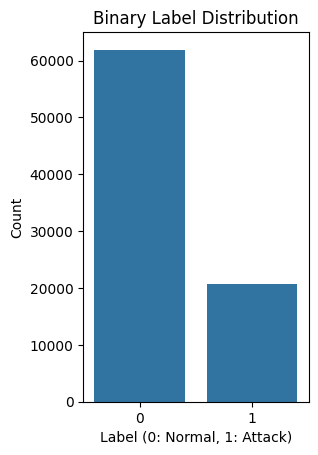

In [14]:
# Binary Label Distribution
plt.subplot(1, 2, 1)
sns.countplot(x=df["Binary_Label"])
plt.title("Binary Label Distribution")
plt.xlabel("Label (0: Normal, 1: Attack)")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

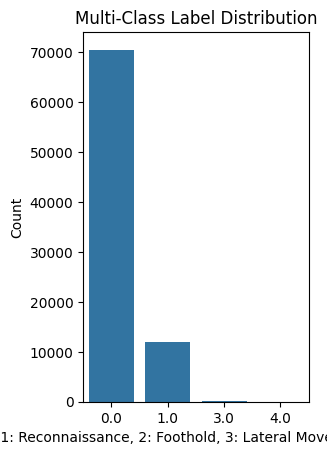

In [15]:
# Multi-Class Label Distribution
plt.subplot(1, 2, 2)
sns.countplot(x=df["Multiclass_Label"])
plt.title("Multi-Class Label Distribution")
plt.xlabel("Label (0: Normal, 1: Reconnaissance, 2: Foothold, 3: Lateral Movement, 4: Data Exfiltration)")
plt.ylabel("Count")